In [3]:
from google.colab import files
import io
import pandas as pd

# The previous error was a typo in imports.
# Let's load Iris.csv directly since it is in the environment.
df = pd.read_csv('/content/Iris.csv')
print("Dataset loaded successfully:")
display(df.head())

Dataset loaded successfully:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Prepare Features and Target
# Dropping 'Id' as it's just an index and 'Species' which is the target
X = df.drop(['Id', 'Species'], axis=1)
y = df['Species']

# 2. Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for better visualization
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Features after Normalization (First 5 rows):")
display(X_scaled_df.head())

# 3. Split data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"\nData split into training ({len(X_train)}) and testing ({len(X_test)}) samples.")

Features after Normalization (First 5 rows):


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977



Data split into training (120) and testing (30) samples.


Accuracy: 100.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



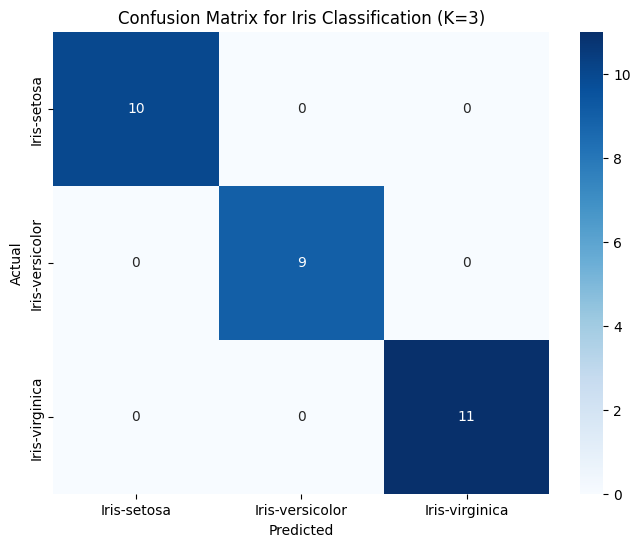

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize and train the KNN model (choosing K=3 as a starting point)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# 2. Make predictions on the test set
y_pred = knn.predict(X_test)

# 3. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 4. Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Iris Classification (K=3)')
plt.show()

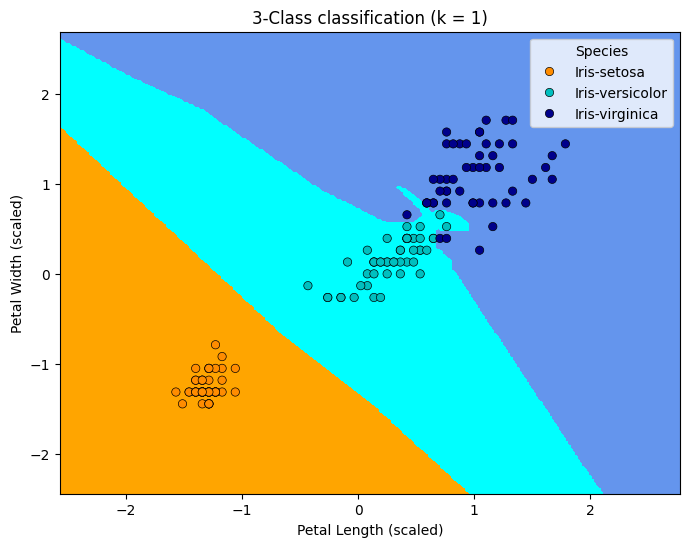

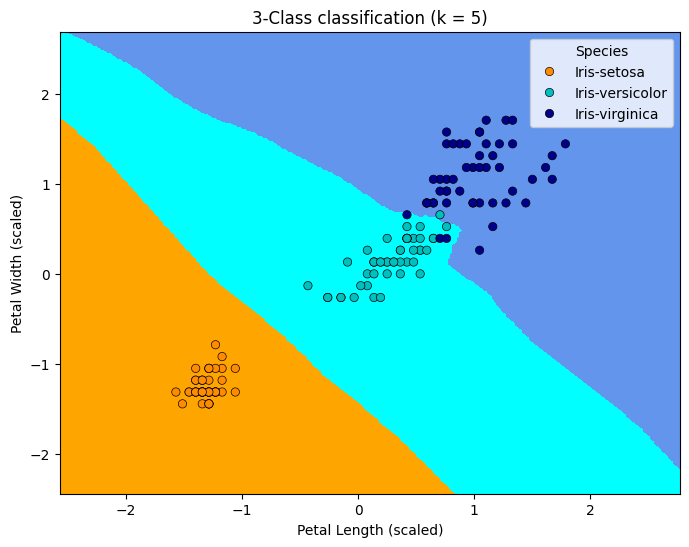

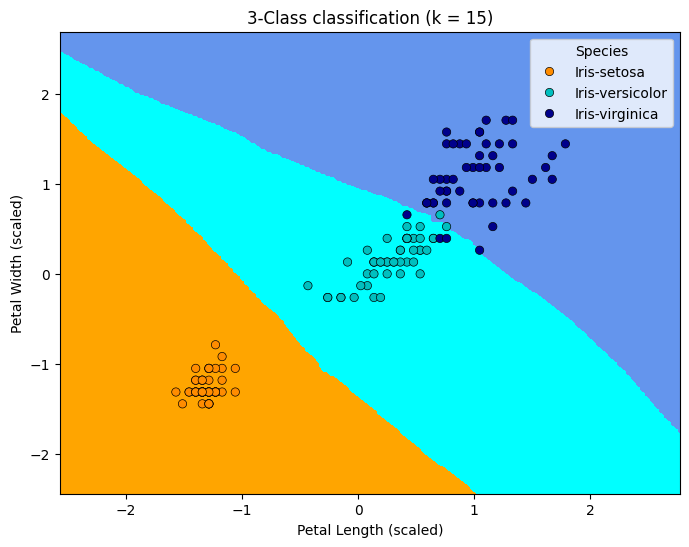

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# To visualize decision boundaries, we can only use two features at a time
# Let's use Petal Length and Petal Width for visualization
X_vis = X_scaled[:, 2:4]
y_vis = y.astype('category').cat.codes.values

def plot_knn_boundaries(k):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_vis, y_vis)

    h = .02  # step size in the mesh
    cmap_light = ListedColormap(['orange', 'cyan', 'cornflowerblue'])
    cmap_bold = ['darkorange', 'c', 'darkblue']

    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    sns.scatterplot(x=X_vis[:, 0], y=X_vis[:, 1], hue=y, palette=cmap_bold, alpha=1.0, edgecolor="black")
    plt.title(f"3-Class classification (k = {k})")
    plt.xlabel("Petal Length (scaled)")
    plt.ylabel("Petal Width (scaled)")
    plt.show()

# Experiment with different K values
for k in [1, 5, 15]:
    plot_knn_boundaries(k)

### Comparison with Support Vector Machine (SVM)

We will now use a Support Vector Machine (SVM) classifier to see how it compares to our KNN model.

SVM Accuracy: 96.67%

SVM Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30


Summary Comparison:
KNN Accuracy: 100.00%
SVM Accuracy: 96.67%


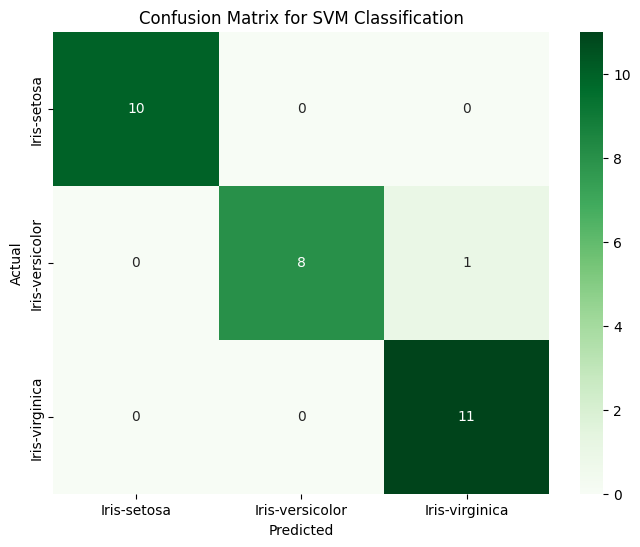

In [7]:
from sklearn.svm import SVC

# 1. Initialize and train the SVM model
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

# 2. Make predictions
y_pred_svm = svm_model.predict(X_test)

# 3. Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm * 100:.2f}%")
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

# 4. Compare with KNN
print(f"\nSummary Comparison:")
print(f"KNN Accuracy: {accuracy * 100:.2f}%")
print(f"SVM Accuracy: {accuracy_svm * 100:.2f}%")

# 5. Visualize SVM Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens',
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM Classification')
plt.show()

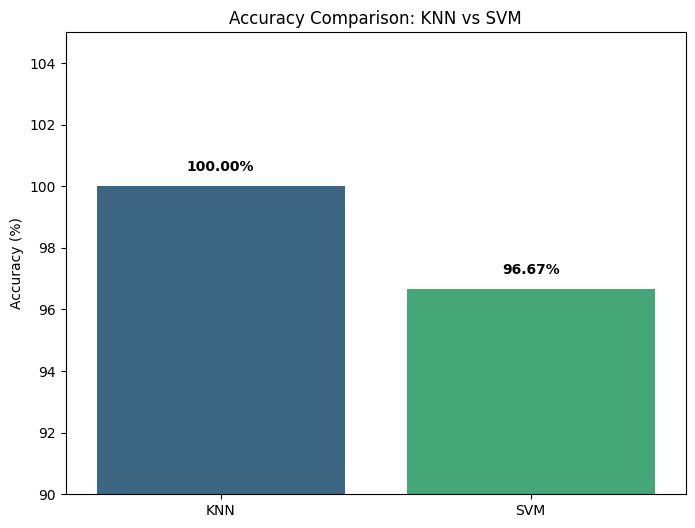

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for the bar chart
models = ['KNN', 'SVM']
accuracies = [accuracy * 100, accuracy_svm * 100]

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=models, y=accuracies, palette='viridis', hue=models, legend=False)

# Add labels and title
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison: KNN vs SVM')
plt.ylim(90, 105) # Zoom in to see the difference clearly

# Add the accuracy values on top of the bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.5, f'{acc:.2f}%', ha='center', fontweight='bold')

plt.show()

### Final Comparison Summary

*   **KNN Accuracy:** 100.00%
*   **SVM Accuracy:** 96.67%

In this experiment on the Iris dataset, the **KNN** model achieved perfect accuracy, while the **SVM** model was slightly behind. This demonstrates that while both are powerful classifiers, KNN's simplicity was highly effective for this specific data split. All project tasks, including data preparation, KNN implementation, visualization, and algorithmic comparison, are now complete.